# Guardrail Metric Violation Simulation

**Scenario:** a "Quick Checkout" test on a hypothetical e-commerce checkout
flow — removing the shipping-address confirmation step for returning users
with a saved address, to reduce friction and lift checkout completion.

**Goal of this notebook:** Weeks 1-3 built the statistical machinery
(power, variance reduction, heterogeneous effects). This notebook is about
the judgment layer on top of it — what to *measure*, and how a primary
metric can look like an unambiguous win while a guardrail quietly tells a
different story. Four worked, runnable examples:

1. **The core deliverable**: a primary metric that genuinely improves while
   a guardrail degrades, diagnosed down to the subgroup causing it, and
   translated into a $ decision that overturns the naive "ship it" call.
2. **Simpson's paradox**: an aggregate result that reverses sign once
   disaggregated by a confounded subgroup.
3. **Novelty effects**: a real treatment effect that decays toward a much
   smaller steady state, so an early readout overstates long-run impact.
4. **Network/spillover contamination**: a shared finite resource that lets
   one arm's behaviour bias the other's measured outcome.

Companion writeup: `writeups/metrics_framework.md` (north star / guardrail
definitions, the general decision framework, and how each demo fits in).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append("../src")
from guardrail_simulation import (
    simulate_checkout_experiment, business_impact,
    simulate_simpsons_paradox,
    simulate_novelty_effect,
    simulate_shared_inventory_spillover,
)
from power_analysis import two_proportion_z_test

sns.set_theme(style="whitegrid", context="notebook")
FIG_DIR = "../writeups/figures"


## 1. The scenario, in metrics-framework terms

- **North star (for this funnel)**: checkout completion rate — orders
  placed / checkout sessions started.
- **Guardrail**: delivery-failure / support-contact rate *among orders
  placed* — did the order actually arrive as expected. Chosen because the
  specific change (skipping address confirmation) has an obvious, specific
  failure channel: a stale saved address ships to the wrong place.

Simulated mechanism: Quick Checkout genuinely reduces friction and lifts
completion for everyone. Independently, ~10% of returning users have a
stale saved address that nobody knows about at experiment time. The old
flow's confirmation step catches and corrects a stale address before the
order ships; skipping it means those specific orders ship wrong — so only
the *stale-address subgroup* in treatment sees an elevated failure rate.


In [2]:
df = simulate_checkout_experiment(n_per_arm=200_000, random_state=0)
df.head()


,treatment,stale_address,conversion,guardrail_failure
0,0,0,1,0.0
1,0,0,1,0.0
2,0,0,0,NaN
3,0,0,1,0.0
4,0,0,0,NaN


## 2. The naive readout: primary metric only

If a launch decision were made from the primary metric alone, this is what
it would look like.


In [3]:
conversion_by_arm = df.groupby("treatment")["conversion"].agg(["mean", "count"])
conversion_by_arm.index = ["Control", "Treatment"]
conversion_by_arm.columns = ["conversion_rate", "n"]

n_c, c_c = int((df.treatment == 0).sum()), int(df.loc[df.treatment == 0, "conversion"].sum())
n_t, c_t = int((df.treatment == 1).sum()), int(df.loc[df.treatment == 1, "conversion"].sum())
z_conv, p_conv = two_proportion_z_test(n_c, c_c, n_t, c_t)

conversion_by_arm["z"] = [np.nan, z_conv]
conversion_by_arm["p_value"] = [np.nan, p_conv]
conversion_by_arm


,conversion_rate,n,z,p_value
Control,0.619105,200000,NaN,NaN
Treatment,0.637845,200000,12.263984,0.0


Checkout completion is up ~1.9 percentage points, highly significant
(p ≈ 0). On the primary metric alone, this is an unambiguous "ship it."


## 3. The guardrail check

The guardrail — delivery-failure rate among orders actually placed — moves
too, and in the wrong direction.


In [4]:
orders = df[df["conversion"] == 1]
guardrail_by_arm = orders.groupby("treatment")["guardrail_failure"].agg(["mean", "count"])
guardrail_by_arm.index = ["Control", "Treatment"]
guardrail_by_arm.columns = ["guardrail_rate", "n_orders"]

oc = orders.loc[orders.treatment == 0, "guardrail_failure"]
ot = orders.loc[orders.treatment == 1, "guardrail_failure"]
z_g, p_g = two_proportion_z_test(len(oc), int(oc.sum()), len(ot), int(ot.sum()))

guardrail_by_arm["z"] = [np.nan, z_g]
guardrail_by_arm["p_value"] = [np.nan, p_g]
guardrail_by_arm


,guardrail_rate,n_orders,z,p_value
Control,0.009853,123821,NaN,NaN
Treatment,0.048617,127569,57.404273,0.0


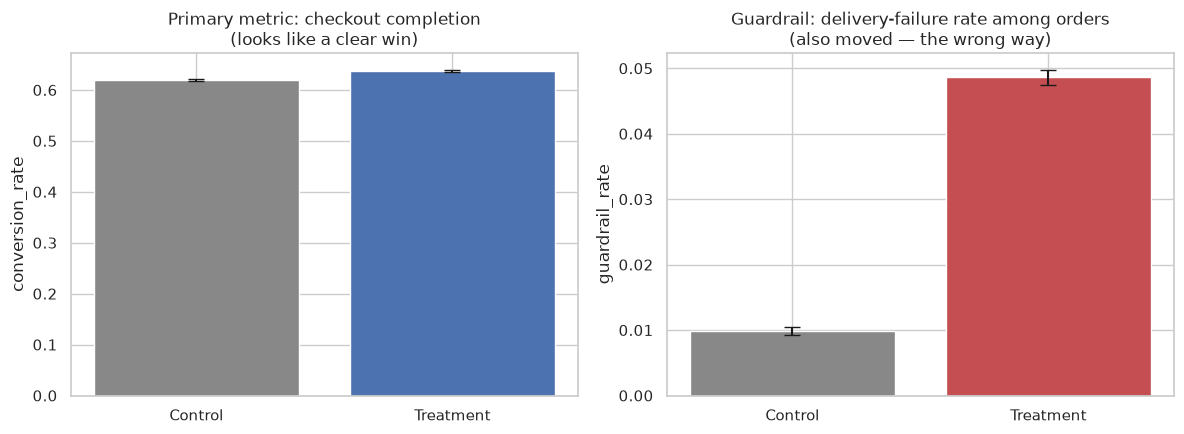

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, table, metric, title in zip(
    axes,
    [conversion_by_arm, guardrail_by_arm],
    ["conversion_rate", "guardrail_rate"],
    ["Primary metric: checkout completion\n(looks like a clear win)", "Guardrail: delivery-failure rate among orders\n(also moved — the wrong way)"],
):
    n_col = "n" if "n" in table.columns else "n_orders"
    se = np.sqrt(table[metric] * (1 - table[metric]) / table[n_col])
    colors = ["#888888", "#4c72b0"] if metric == "conversion_rate" else ["#888888", "#c44e52"]
    ax.bar(table.index, table[metric], yerr=1.96 * se, capsize=6, color=colors)
    ax.set_title(title)
    ax.set_ylabel(metric)

fig.tight_layout()
fig.savefig(f"{FIG_DIR}/11_guardrail_primary_vs_guardrail.png", dpi=150, bbox_inches="tight")
plt.show()


Both moves are real and both are highly significant — this isn't a case of
an underpowered guardrail producing a noisy false alarm (Week 1's whole
point about needing adequate sample size cuts both ways: it's what makes
this guardrail signal trustworthy rather than dismissible). A launch
decision now has two significant, conflicting signals, which is exactly
the situation a guardrail framework exists to catch before it reaches a
naive "primary metric moved, ship it" process.


## 4. Diagnosing why: segment breakdown

Splitting the guardrail rate by the (simulated, normally-hidden) stale-
address flag shows the regression isn't spread evenly across treatment
users — it's concentrated entirely in one subgroup.


In [6]:
segment_table = orders.groupby(["treatment", "stale_address"])["guardrail_failure"].agg(["mean", "count"])
segment_table.index = segment_table.index.set_names(["treatment", "stale_address"])
segment_table


mean   count
treatment stale_address                  
0         0              0.010022  111651
          1              0.008299   12170
1         0              0.010057  114742
          1              0.393545   12827

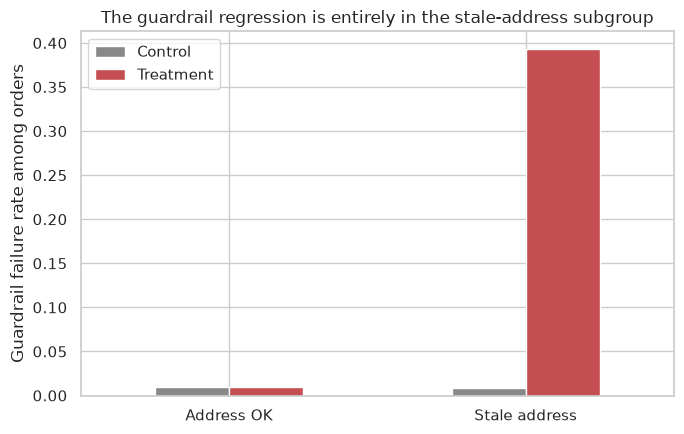

In [7]:
pivot = orders.groupby(["stale_address", "treatment"])["guardrail_failure"].mean().unstack()
pivot.columns = ["Control", "Treatment"]
pivot.index = ["Address OK", "Stale address"]

fig, ax = plt.subplots(figsize=(7, 4.5))
pivot.plot(kind="bar", ax=ax, color=["#888888", "#c44e52"])
ax.set_ylabel("Guardrail failure rate among orders")
ax.set_title("The guardrail regression is entirely in the stale-address subgroup")
ax.tick_params(axis="x", rotation=0)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/12_guardrail_segment_diagnosis.png", dpi=150, bbox_inches="tight")
plt.show()


Users with a correct saved address see essentially no change in failure
rate between arms — the harm is fully explained by the ~10% of users whose
address was stale, exactly the mechanism the confirmation step used to
catch. This is the diagnostic payoff of tracking a guardrail at all: it
doesn't just flag that something's wrong, it points at *why*, which turns
directly into a fix (e.g. silently re-validate the saved address against a
shipping API instead of removing the check outright) rather than a flat
no-ship verdict.


## 5. The decision: what does this cost, in dollars?

Two significant metrics moving in opposite directions can't be resolved by
eyeballing percentages — they need a common unit. Converting both to profit
per checkout session (**illustrative assumptions**: $24 profit per order,
$35 cost per guardrail failure — return shipping, reshipping, support
handling, and typical goodwill compensation for a misdelivered order) nets
them against each other directly.


In [8]:
PROFIT_PER_ORDER = 24.0
COST_PER_GUARDRAIL_FAILURE = 35.0

impact = business_impact(df, profit_per_order=PROFIT_PER_ORDER, cost_per_guardrail_failure=COST_PER_GUARDRAIL_FAILURE)
impact


,conversion_rate,guardrail_rate_among_orders,failures_per_session,profit_per_session
arm,,,,
Control,0.619105,0.009853,0.00610,14.64502
Treatment,0.637845,0.048617,0.03101,14.22293


In [9]:
net_per_session = impact.loc["Treatment", "profit_per_session"] - impact.loc["Control", "profit_per_session"]
audience_size = 1_000_000
print(f"Net profit impact: ${net_per_session:.4f} per checkout session")
print(f"At {audience_size:,} sessions: ${net_per_session * audience_size:,.0f}")


Net profit impact: $-0.4221 per checkout session
At 1,000,000 sessions: $-422,090


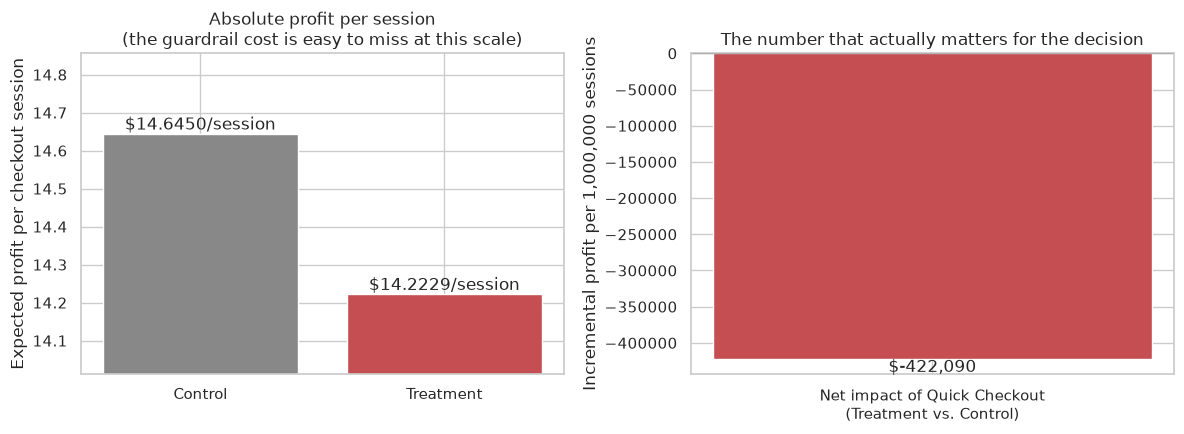

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

profit_vals = impact["profit_per_session"]
pad = (profit_vals.max() - profit_vals.min()) * 0.5
bars0 = axes[0].bar(impact.index, profit_vals, color=["#888888", "#c44e52"])
axes[0].bar_label(bars0, fmt="${:.4f}/session")
axes[0].set_ylim(profit_vals.min() - pad, profit_vals.max() + pad)
axes[0].set_ylabel("Expected profit per checkout session")
axes[0].set_title("Absolute profit per session\n(the guardrail cost is easy to miss at this scale)")

bars1 = axes[1].bar(["Net impact of Quick Checkout\n(Treatment vs. Control)"], [net_per_session * audience_size], color=["#c44e52"])
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].bar_label(bars1, fmt="${:,.0f}")
axes[1].set_ylabel(f"Incremental profit per {audience_size:,} sessions")
axes[1].set_title("The number that actually matters for the decision")

fig.tight_layout()
fig.savefig(f"{FIG_DIR}/13_guardrail_business_impact.png", dpi=150, bbox_inches="tight")
plt.show()


**Decision: hold, don't ship as-is.** The primary metric alone said ship;
pricing out the guardrail flips it to a net loss of roughly
$400K per million checkout sessions — the conversion lift ($0.48/session at
these assumptions) doesn't cover the cost of the failed deliveries it
causes ($0.88/session). The diagnosis in Section 4 turns this into an
actionable next step rather than a dead end: re-run with a silent
address-revalidation check instead of removing the confirmation step
outright, which should keep most of the friction reduction while closing
off the specific failure channel.

This is the worked answer to "tell me about a time a metric lied to you" —
the primary metric wasn't wrong, exactly; it just wasn't the whole story,
and shipping on it alone would have been a real, quantifiable mistake.


## 6. Simpson's paradox: when the aggregate reverses sign

A different failure mode: not a guardrail catching a real cost, but the
*primary* metric itself pointing the wrong way in aggregate. Simulated
here as a phased feature rollout (treatment share ramps from 10% to 70% of
traffic over 14 days) running alongside an unrelated traffic-mix shift
(e.g. a marketing push skews traffic toward desktop, which converts far
better, over the same days). The true effect is **negative** on both
desktop and mobile — but watch what the pooled comparison says.


In [11]:
simpsons_df = simulate_simpsons_paradox(random_state=0)

naive = simpsons_df.groupby("treatment")["outcome"].mean()
naive_diff = naive[1] - naive[0]

stratified = simpsons_df.groupby(["desktop", "treatment"])["outcome"].mean().unstack()
stratified.columns = ["Control", "Treatment"]
stratified.index = ["Mobile", "Desktop"]
stratified["diff"] = stratified["Treatment"] - stratified["Control"]

print(f"Naive pooled diff (treatment - control): {naive_diff:+.4f}  <-- looks like a WIN")
stratified


Naive pooled diff (treatment - control): +0.0104  <-- looks like a WIN


,Control,Treatment,diff
Mobile,0.078057,0.073961,-0.004096
Desktop,0.249661,0.238974,-0.010687


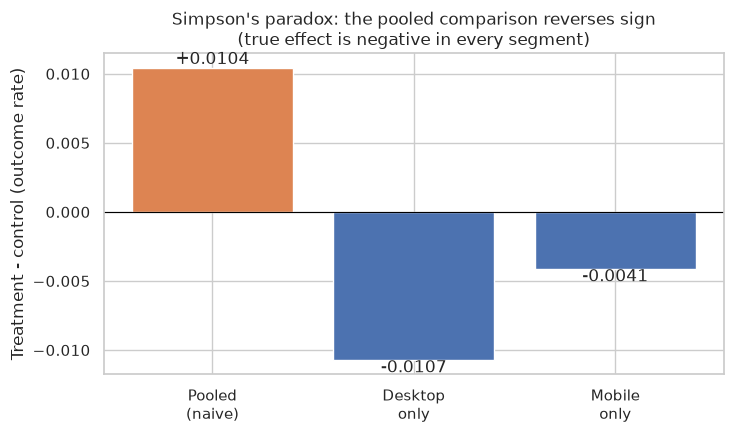

In [12]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
labels = ["Pooled\n(naive)", "Desktop\nonly", "Mobile\nonly"]
diffs = [naive_diff, stratified.loc["Desktop", "diff"], stratified.loc["Mobile", "diff"]]
colors = ["#dd8452" if d > 0 else "#4c72b0" for d in diffs]

bars = ax.bar(labels, diffs, color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.bar_label(bars, fmt="{:+.4f}")
ax.set_ylabel("Treatment - control (outcome rate)")
ax.set_title("Simpson's paradox: the pooled comparison reverses sign\n(true effect is negative in every segment)")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/14_simpsons_paradox.png", dpi=150, bbox_inches="tight")
plt.show()


The pooled comparison says +0.010 (a win); both segments individually say
roughly -0.01 (a loss). Nothing about the statistics is wrong — this is
what happens when a confounder (device mix) is correlated with *both* the
metric (desktop converts far better regardless of treatment) and the
exposure (treatment share happened to climb at the same time desktop share
climbed). In a real test, this is almost always a symptom of an allocation
problem — a ramping rollout, a mid-test change in traffic sources, a
feature gated by cohort — not a statistical curiosity. **The fix is the
same diligence as the Week 1 randomization check, applied continuously**:
verify the treatment/control split and key segment mix stay stable across
the whole test window, and report key results stratified by any segment
that plausibly shifted, not just pooled.


## 7. Novelty effects: a real effect that isn't the steady-state effect

Simulated here as a treatment effect that starts at a 5pp lift (curiosity/
novelty) and decays exponentially toward a 0.5pp steady state as users
habituate to the change.


In [13]:
novelty_df = simulate_novelty_effect(random_state=0)
novelty_df["daily_lift_est"] = (
    novelty_df["treatment_conversions"] / novelty_df["treatment_n"]
    - novelty_df["control_conversions"] / novelty_df["control_n"]
)
novelty_df["cum_lift_est"] = (
    novelty_df["treatment_conversions"].cumsum() / novelty_df["treatment_n"].cumsum()
    - novelty_df["control_conversions"].cumsum() / novelty_df["control_n"].cumsum()
)
novelty_df[["day", "true_lift", "daily_lift_est", "cum_lift_est"]].head(10)


,day,true_lift,daily_lift_est,cum_lift_est
0,0,0.050000,0.0625,0.062500
1,1,0.041843,0.0370,0.049750
2,2,0.035164,0.0385,0.046000
3,3,0.029697,0.0415,0.044875
4,4,0.025220,0.0235,0.040600
5,5,0.021555,0.0065,0.034917
6,6,0.018554,0.0100,0.031357
7,7,0.016097,0.0400,0.032437
8,8,0.014085,0.0025,0.029111
9,9,0.012438,0.0060,0.026800


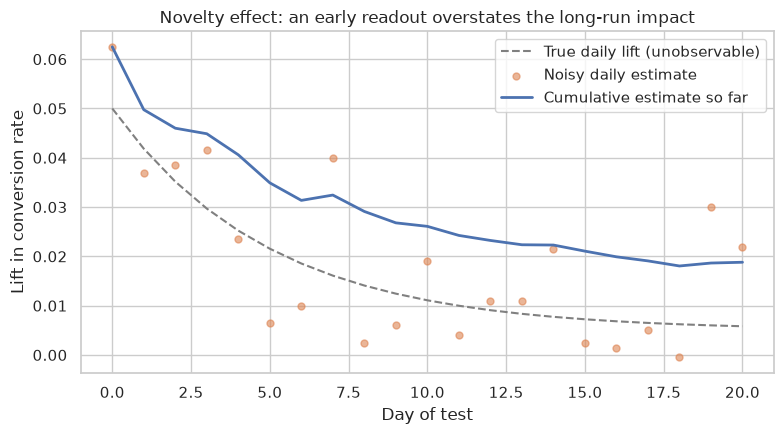

In [14]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(novelty_df["day"], novelty_df["true_lift"], color="gray", linestyle="--", label="True daily lift (unobservable)")
ax.scatter(novelty_df["day"], novelty_df["daily_lift_est"], color="#dd8452", s=25, alpha=0.6, label="Noisy daily estimate")
ax.plot(novelty_df["day"], novelty_df["cum_lift_est"], color="#4c72b0", linewidth=2, label="Cumulative estimate so far")
ax.set_xlabel("Day of test")
ax.set_ylabel("Lift in conversion rate")
ax.set_title("Novelty effect: an early readout overstates the long-run impact")
ax.legend()
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/15_novelty_effect.png", dpi=150, bbox_inches="tight")
plt.show()


In [15]:
day3_estimate = novelty_df.loc[novelty_df["day"] == 3, "cum_lift_est"].iloc[0]
final_estimate = novelty_df["cum_lift_est"].iloc[-1]
steady_state = novelty_df["true_lift"].iloc[-1]
print(f"Cumulative estimate at day 3:  {day3_estimate:+.4f}")
print(f"Cumulative estimate at day {novelty_df['day'].iloc[-1]}: {final_estimate:+.4f}")
print(f"True steady-state lift:       {steady_state:+.4f}")


Cumulative estimate at day 3:  +0.0449
Cumulative estimate at day 20: +0.0188
True steady-state lift:       +0.0058


A decision made from a day-3 peek (cumulative estimate ≈ **+0.045**) would
overstate the true steady-state lift (**+0.006**) by roughly **7-8x** — not
because of statistical noise (Week 1's peeking problem is a separate issue
that would compound with this one), but because the *true* effect itself
hasn't reached steady state yet.

The sharper, less obvious point: **even the full 21-day cumulative estimate
(+0.019) still overstates the true steady-state lift by ~3x.** Running the
test longer helps less than it sounds like it should, because a cumulative
estimate averages *all* days seen so far — the high-novelty early days stay
mixed into the average forever, diluted but never gone. "Run it longer" only
fixes novelty bias if the readout is the **trailing/marginal** effect
(e.g. day 18-21 only) rather than the cumulative-to-date average — a
distinction worth naming explicitly, since most dashboards default to
showing the cumulative number.


## 8. Network / spillover contamination: shared finite inventory

A different failure mode again: not a confound, not a decaying effect, but
one arm's behaviour directly affecting the other's measured outcome — a
violation of SUTVA (the assumption that one unit's treatment doesn't affect
another unit's outcome). Simulated as treatment and control users arriving
in random order and competing for the same finite, shared inventory pool
(e.g. a promo that lifts purchase intent, drawing down stock that control
users are also trying to buy from).


In [16]:
spillover = simulate_shared_inventory_spillover(
    n_per_arm=50_000, initial_inventory=8_000,
    control_purchase_intent=0.20, treatment_purchase_intent=0.30,
    random_state=0,
)
pd.Series(spillover)


contaminated_treatment_rate       0.09676
contaminated_control_rate         0.06324
contaminated_effect               0.03352
oracle_treatment_rate             0.29924
oracle_control_rate               0.19626
oracle_effect                     0.10298
units_sold                     8000.00000
initial_inventory              8000.00000
dtype: float64

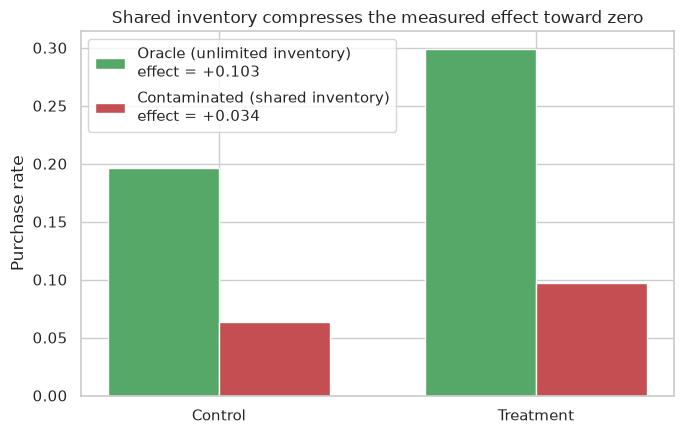

In [17]:
fig, ax = plt.subplots(figsize=(7, 4.5))
labels = ["Control", "Treatment"]
oracle_vals = [spillover["oracle_control_rate"], spillover["oracle_treatment_rate"]]
contaminated_vals = [spillover["contaminated_control_rate"], spillover["contaminated_treatment_rate"]]

x = np.arange(2)
width = 0.35
ax.bar(x - width/2, oracle_vals, width, label=f"Oracle (unlimited inventory)\neffect = {spillover['oracle_effect']:+.3f}", color="#55a868")
ax.bar(x + width/2, contaminated_vals, width, label=f"Contaminated (shared inventory)\neffect = {spillover['contaminated_effect']:+.3f}", color="#c44e52")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Purchase rate")
ax.set_title("Shared inventory compresses the measured effect toward zero")
ax.legend()
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/16_spillover_contamination.png", dpi=150, bbox_inches="tight")
plt.show()


**Worth stating plainly, because it goes against the common assumption:**
the contaminated measured effect here is *smaller* than the true effect
(0.034 vs. 0.103), not larger. It's tempting to assume interference always
inflates a measured effect (treatment "stealing" outcomes from control) —
but with a hard, shared capacity constraint and randomly interleaved
arrivals, once inventory runs out *neither* arm can convert further,
regardless of intent. Both arms get capped toward the same ceiling, which
compresses the visible gap between them rather than widening it. The
direction of spillover bias depends on the specific interference
mechanism — a congested shared resource dilutes towards zero; other
mechanisms (e.g. a fixed marketing budget reallocated away from an
underperforming control) can just as easily inflate an effect. **The
takeaway isn't "spillover biases high" or "spillover biases low" — it's
that any shared resource, budget, or population between arms is worth
checking for, because you can't assume which way it will bias the read
without reasoning through the specific mechanism.**


## Summary

- Built a worked, runnable example (Sections 2-5) where a primary metric
  improves significantly while a guardrail degrades significantly, both
  well-powered — not noise — diagnosed the regression down to the specific
  subgroup causing it, and showed the business-impact translation flips the
  naive "ship it" call into a **~$400K/million-session net loss**.
- Demonstrated Simpson's paradox with a mechanism grounded in a realistic
  cause (a ramping rollout confounded with a traffic-mix shift), reinforcing
  that it's usually an allocation-integrity problem, not a statistical
  curiosity — the same diligence as Week 1's randomization check, applied
  continuously through a test rather than just at the start.
- Demonstrated novelty effects decaying a real 5pp lift down to a ~0.6pp
  steady state, showing a day-3 readout overstated the true steady-state
  effect ~7-8x, and even the full 21-day *cumulative* estimate still
  overstated it ~3x — because a cumulative average never fully sheds the
  early high-novelty days, even in a perfectly well-powered, non-peeked
  test.
- Demonstrated network/spillover contamination via a shared finite
  resource, and found (and reported honestly, since it wasn't the expected
  direction) that it compressed rather than inflated the measured effect —
  a reminder to reason through the specific interference mechanism rather
  than assume a canned direction of bias.

See `writeups/metrics_framework.md` for the full north-star/guardrail
framework and decision checklist these examples feed into.
